# Import Libraries

In [ ]:
from google.colab import files, drive

In [ ]:
import pandas as pd
import numpy as np
import io
import warnings
# !pip install missingno
import missingno as msno
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import copy

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch as t
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from tqdm import tqdm

# Data Cleaning & EDA

In [ ]:
drive.mount('/content/drive')
df = pd.read_csv("drive/My Drive/ML/Datathon #4 - mhealth Dataset - HAD7001.csv") # Change as needed

# Display the first few rows of the dataset to ensure it's loaded correctly
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0,subject1


In [ ]:
df.columns

Index(['alx', 'aly', 'alz', 'glx', 'gly', 'glz', 'arx', 'ary', 'arz', 'grx',
       'gry', 'grz', 'Activity', 'subject'],
      dtype='object')

In [ ]:
print(df.shape)

(999999, 14)


In [ ]:
df.isna().sum() # Checking for missingness

,0
alx,0
aly,0
alz,0
glx,0
gly,0
glz,0
arx,0
ary,0
arz,0
grx,0


In [ ]:
df['subject'].value_counts()

,count
subject,
subject1,161280
subject2,130561
subject8,129024
subject3,122112
subject5,119808
subject4,116736
subject7,104448
subject6,98304
subject9,17726


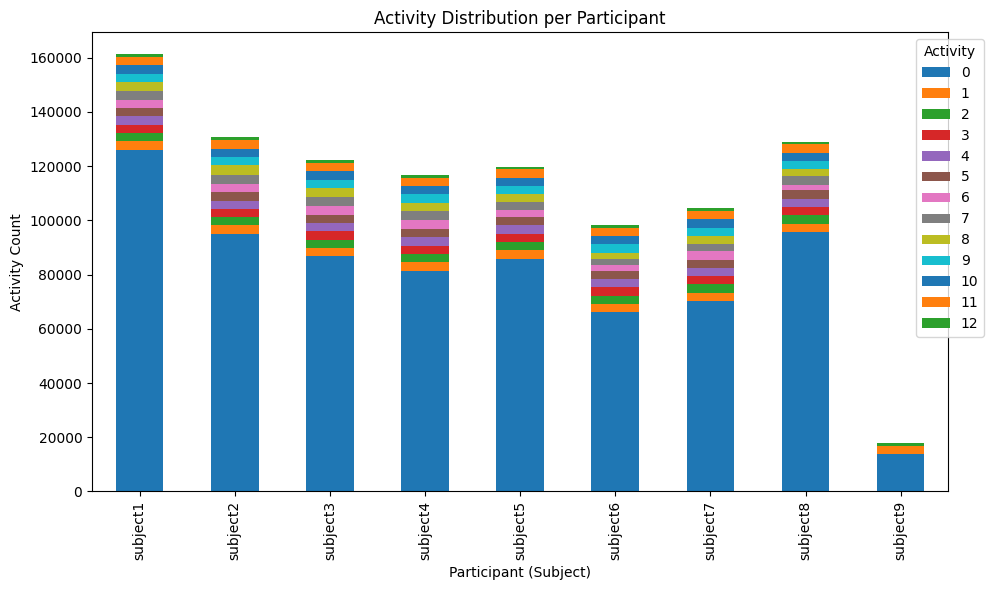

In [ ]:
# Making a plot of how many times each subject appears in each activity

# Count combinations
counts = df.groupby(['subject', 'Activity']).size().unstack(fill_value=0)

counts.plot(kind='bar', stacked=True, figsize=(10,6))

plt.xlabel("Participant (Subject)")
plt.ylabel("Activity Count")
plt.title("Activity Distribution per Participant")
plt.legend(title="Activity", bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

In [ ]:
df = df[df['subject'] != 'subject9'] # Dropping Subject 9 since there isn't enough activity information about the subject

In [ ]:
df['subject'].value_counts()

,count
subject,
subject1,161280
subject2,130561
subject8,129024
subject3,122112
subject5,119808
subject4,116736
subject7,104448
subject6,98304


In [ ]:
df = df[df['Activity'] != 0].reset_index(drop=True) # Removing activity 0 due to research question
df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.6493,-9.4517,0.37683,-0.20965,-0.88931,-0.50884,-2.8439,-9.0618,1.8177,-0.058824,-0.93429,-0.34483,1,subject1
1,2.4157,-9.5306,0.40179,-0.20965,-0.88931,-0.50884,-2.9935,-9.2048,1.5189,-0.058824,-0.93429,-0.34483,1,subject1
2,2.3865,-9.5991,0.48141,-0.20037,-0.86867,-0.50688,-2.8846,-9.1945,1.5507,-0.058824,-0.93429,-0.34483,1,subject1
3,2.3758,-9.5997,0.42919,-0.20037,-0.86867,-0.50688,-2.9245,-9.1746,1.5413,-0.078431,-0.93429,-0.34052,1,subject1
4,2.3239,-9.5406,0.40038,-0.20037,-0.86867,-0.50688,-2.8963,-9.2039,1.6127,-0.078431,-0.93429,-0.34052,1,subject1


In [ ]:
df.shape

(275151, 14)

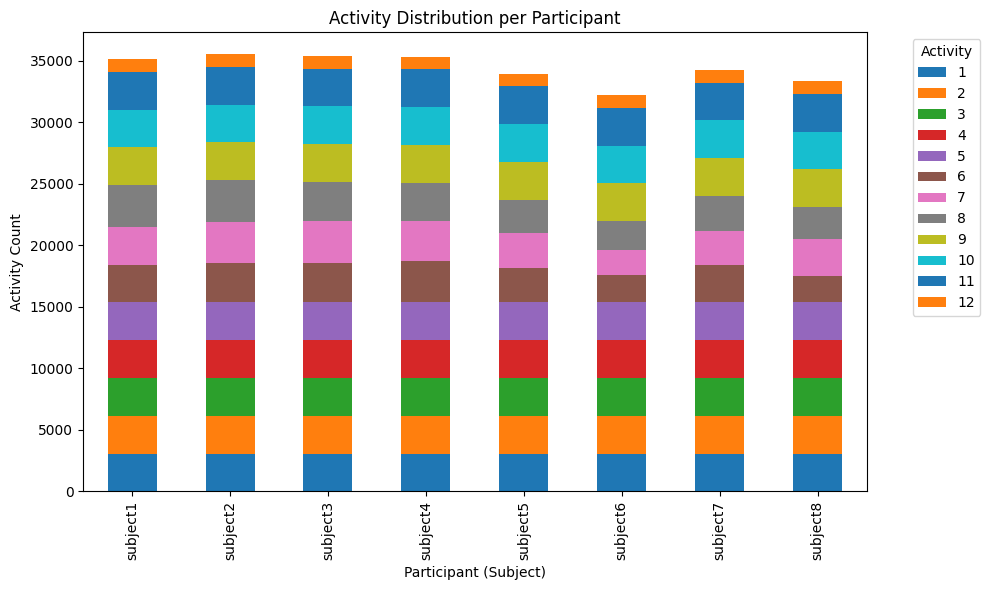

In [ ]:
# Count combinations
counts = df.groupby(['subject', 'Activity']).size().unstack(fill_value=0)

counts.plot(kind='bar', stacked=True, figsize=(10,6))

plt.xlabel("Participant (Subject)")
plt.ylabel("Activity Count")
plt.title("Activity Distribution per Participant")
plt.legend(title="Activity", bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

<Axes: >

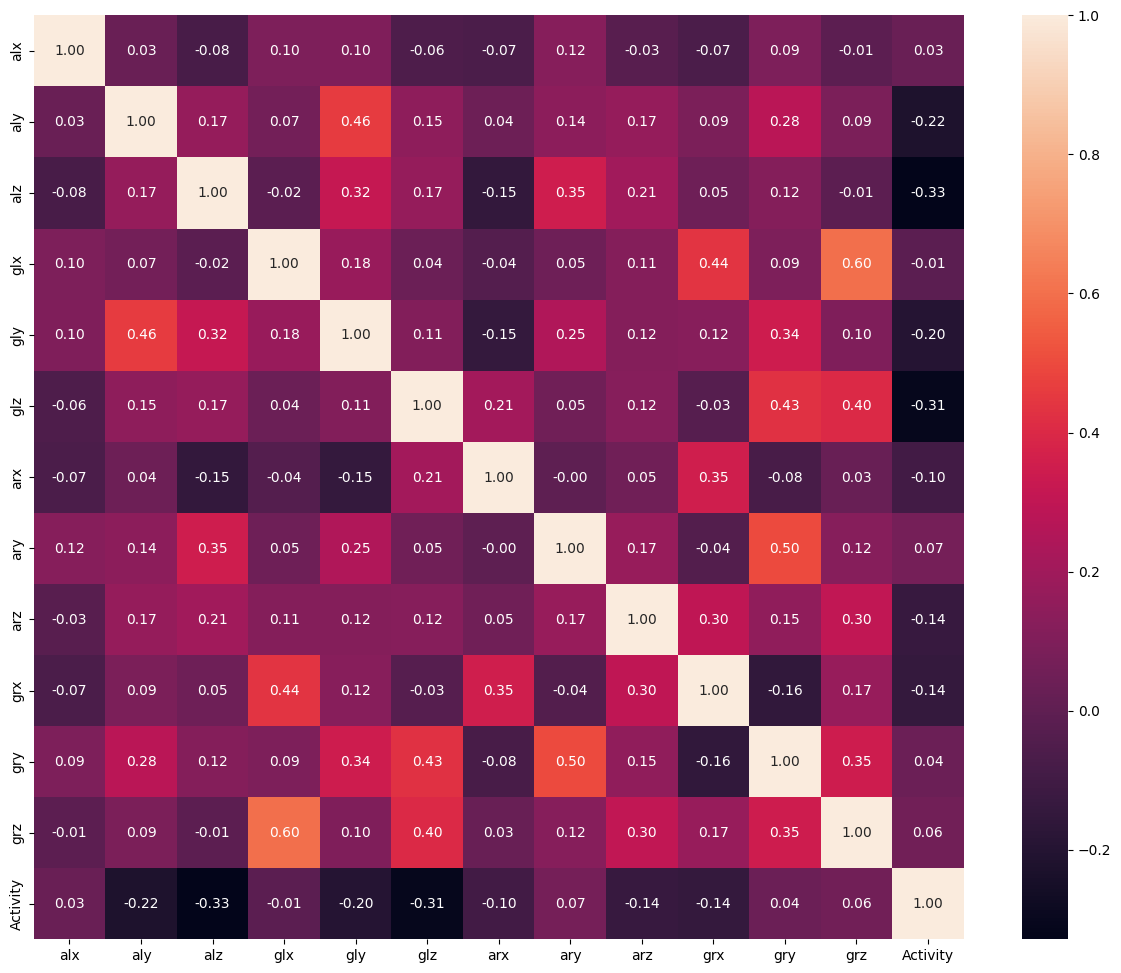

In [ ]:
# Correlation matrix to quantify relationships
qualitative_columns = ['subject']
corr_matrix = df.iloc[:,:-1].corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")

In [ ]:
df['subject'].value_counts()

,count
subject,
subject2,35532
subject3,35380
subject4,35328
subject1,35174
subject7,34253
subject5,33947
subject8,33332
subject6,32205


You can convert numerical Values of Activity to categories here

# Data Splitting (Train & Test)

In [ ]:
# Grouping by 'subject' and creating a list of dataframes, one per group
grouped = df.groupby('subject')
grouped_dfs = [group for _, group in grouped]

# Splitting the groups into training and test sets with an 80:20 ratio
train_groups, test_groups = train_test_split(grouped_dfs, test_size=0.2, random_state=42)

# Reassembling the training and test datasets from the groups
train_df = pd.concat(train_groups)
test_df = pd.concat(test_groups)

# Displaying the shape of the training and test sets
train_df_shape = train_df.shape
test_df_shape = test_df.shape

train_df_shape, test_df_shape

((207414, 14), (67737, 14))

## Normalization of the Train Set

In [ ]:
# Normalization of the Train Set

# Identifying numerical columns which we will normalize (excluding 'patient_nbr' and 'readmitted')
numerical_columns = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_columns.remove('Activity')
if 'subject' in numerical_columns:
    numerical_columns.remove('subject')
# Initializing the StandardScaler
scaler = StandardScaler()

# Fitting the scaler to the training data and transforming both training and test data
train_df[numerical_columns] = scaler.fit_transform(train_df[numerical_columns])
test_df[numerical_columns] = scaler.transform(test_df[numerical_columns])

# Checking the first few rows of the normalized training data
train_df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,0.243975,-0.069035,0.170485,-0.630257,-0.840154,-0.788474,0.041904,-0.485958,-0.126266,0.211671,-1.004809,-1.529028,1,subject1
1,0.188259,-0.084214,0.174366,-0.630257,-0.840154,-0.788474,0.016937,-0.507858,-0.199173,0.211671,-1.004809,-1.529028,1,subject1
2,0.181294,-0.097393,0.186745,-0.611071,-0.792613,-0.784992,0.035111,-0.506281,-0.191413,0.211671,-1.004809,-1.529028,1,subject1
3,0.178742,-0.097509,0.178626,-0.611071,-0.792613,-0.784992,0.028452,-0.503233,-0.193707,0.177052,-1.004809,-1.520266,1,subject1
4,0.166364,-0.086138,0.174147,-0.611071,-0.792613,-0.784992,0.033159,-0.507720,-0.176285,0.177052,-1.004809,-1.520266,1,subject1


## Sequence Generation

The dataset is ordered in a chronological order by subject with the assumption that it was done over time

### By Activity and Subject

In [ ]:
def Create_ID_column_for_participant_and_activity(df, participant_ID:str, activity:str, count_col='activity_participant_ID'):
    """
    This function assigns a unique identifier to each participant-activity sequence in the dataframe.
    Every time a participant switches activities, a new ID is assigned in the specified column.

    This assumes that the data is in chronological order and accounts for cases where a participant
    engages in multiple activities over time (e.g., switching from activity 0 to activity 1, back to 0,
    and then to activity 2). Each transition triggers a new ID to be created, aiding in grouping and
    sequence generation.

    Parameters:
        df (pd.DataFrame): The input dataframe.
        participant_ID (str): Column name representing the participant identifier.
        activity (str): Column name representing the activity label.
        count_col (str, optional): Name of the new column to store sequence IDs. Default is 'activity_participant_ID'.

    Returns:
        pd.DataFrame: The dataframe with an added column assigning unique sequence IDs.
    """
    df[count_col] = 0  # initialize the new ID column with 0

    # initialize variables to store last values
    last_subject = None
    last_activity = None
    count = 0

    # loop through the rows of the df
    for index, row in df.iterrows():
        current_subject = row[participant_ID]
        current_activity = row[activity]

        # check if the values are the same as the last row
        if current_subject == last_subject and current_activity == last_activity:
            df.at[index, count_col] = count
        else:
            count += 1
            df.at[index, count_col] = count

        # update the last values
        last_subject = current_subject
        last_activity = current_activity

    return df

(72,3124,12)

### By Sequencing

In [ ]:
def create_sliding_windows(df, subject_col='subject', activity_col='Activity',
                           window_size=200, stride=100):

    X = []
    y = []

    # group by subject
    for subject, group in df.groupby(subject_col):

        # sort to ensure chronological order
        group = group.sort_index()

        features = group.drop(columns=[subject_col, activity_col]).values
        labels = group[activity_col].values

        # create sliding windows
        for start in range(0, len(features) - window_size + 1, stride):
            end = start + window_size

            window = features[start:end]
            label = labels[end - 1]   # label of last timestep

            X.append(window)
            y.append(label)

    X = np.array(X)
    y = np.array(y)

    return X, y

In [ ]:
window_size = 200
stride = 100

X_train, y_train = create_sliding_windows(
    train_df,
    subject_col='subject',
    activity_col='Activity',
    window_size=window_size,
    stride=stride
)

X_test, y_test = create_sliding_windows(
    test_df,
    subject_col='subject',
    activity_col='Activity',
    window_size=window_size,
    stride=stride
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2065, 200, 12)
y_train shape: (2065,)
X_test shape: (675, 200, 12)
y_test shape: (675,)


In [ ]:
print("Unique y_train labels:", np.unique(y_train))
print("Unique y_test labels:", np.unique(y_test))
print("Number of unique train labels:", len(np.unique(y_train)))

Unique y_train labels: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Unique y_test labels: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Number of unique train labels: 12


# RNN with PyTorch

## Hyperparameters Set1

In [ ]:
# Hyperparameters
input_size = X_train.shape[2]
hidden_size = 256  # Number of hidden units in RNN
num_classes = 13  # For three-class classification
epochs = 100
learning_rate = 0.0001
batch_size = 512
landa = 0.000001  # Regularization term (lambda)

# Data preparation
train_dataset = TensorDataset(t.tensor(X_train, dtype=t.float32), t.tensor(y_train, dtype=t.long))
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(t.tensor(X_test, dtype=t.float32), t.tensor(y_test, dtype=t.long))
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# RNN layers and additional fully connected layer
rnn_layer1 = nn.RNN(input_size, hidden_size, batch_first=True)
dropout1 = nn.Dropout(0.5)  # Add dropout between RNN layers
# rnn_layer2 = nn.RNN(hidden_size, hidden_size, batch_first=True)
# dropout2 = nn.Dropout(0.5)  # Add dropout between RNN layers
fc_layer1 = nn.Linear(hidden_size, hidden_size // 2)  # Additional fully connected layer
fc_layer2 = nn.Linear(hidden_size  // 2, num_classes)  # Final output layer

# Dropout layer
dropout_fc = nn.Dropout(0.2)  # Add dropout between fully connected layers

# Activation function
relu = nn.ReLU()

# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
# optimizer = Adam(list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)
# optimizer = Adam(list(rnn_layer1.parameters())+ list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)

# Lists to store accuracies and losses
all_loss = []
train_accuracy_list = []
validation_accuracy_list = []
train_loss_list = []

# Training loop
for epoch in range(epochs):

    if epoch % 10 == 0:
        learning_rate *= 0.9  # Learning rate scheduling

    optimizer = Adam(list(rnn_layer1.parameters())+ list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)

    per_epoch_loss_list = []
    for X, Y in train_data_loader:
        # Forward pass through layers
        out, _ = rnn_layer1(X)
        out = dropout1(out)  # Apply dropout between RNN layers
        # out, _ = rnn_layer2(out)
        # out = dropout2(out)  # Apply dropout between RNN layers
        out = out[:, -1, :]  # Get the last output of the sequence
        out = relu(fc_layer1(out))  # Apply activation function after first fully connected layer
        out = dropout_fc(out)  # Apply dropout between fully connected layers
        out = fc_layer2(out)

        # Regularization
        # l2_term = sum([(w ** 2).sum() for w in list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters())])
        # l2_term = sum([(w ** 2).sum() for w in list(rnn_layer1.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters())])
        # loss = loss_fn(out, Y) + landa * l2_term
        loss = loss_fn(out, Y)
        per_epoch_loss_list.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # max_iter -=1
        # if max_iter == 0:
        #     break
    all_loss += per_epoch_loss_list

    # Evaluation on training and validation data
    rnn_layer1.eval()
    # rnn_layer2.eval()
    fc_layer1.eval()
    fc_layer2.eval()

    with t.no_grad():
        # Training data
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            out, _ = rnn_layer1(X)
            # out, _ = rnn_layer2(out)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            train_total += Y.size(0)
            train_correct += (predicted == Y).sum().item()
        train_accuracy = 100 * train_correct / train_total

        # Validation data
        validation_correct, validation_total = 0, 0
        for X, Y in test_data_loader:
            out, _ = rnn_layer1(X)
            # out, _ = rnn_layer2(out)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            validation_total += Y.size(0)
            validation_correct += (predicted == Y).sum().item()
        validation_accuracy = 100 * validation_correct / validation_total

        # Print accuracy for the current epoch
        print(f'Epoch {epoch}/{epochs} ---> Train Accuracy: {train_accuracy}%, Validation Accuracy: {validation_accuracy}%')

        # Append accuracy values to lists
        train_accuracy_list.append(train_accuracy)
        validation_accuracy_list.append(validation_accuracy)

    # Calculate and append the average loss for the epoch
    train_loss_list.append(sum(per_epoch_loss_list) / len(per_epoch_loss_list))

    # Set the model back to train mode
    rnn_layer1.train()
    # rnn_layer2.train()
    fc_layer1.train()
    fc_layer2.train()


Epoch 0/100 ---> Train Accuracy: 12.397094430992736%, Validation Accuracy: 6.518518518518518%
Epoch 1/100 ---> Train Accuracy: 21.937046004842614%, Validation Accuracy: 8.296296296296296%
Epoch 2/100 ---> Train Accuracy: 24.019370460048425%, Validation Accuracy: 14.814814814814815%
Epoch 3/100 ---> Train Accuracy: 26.973365617433416%, Validation Accuracy: 21.333333333333332%
Epoch 4/100 ---> Train Accuracy: 31.331719128329297%, Validation Accuracy: 22.074074074074073%
Epoch 5/100 ---> Train Accuracy: 35.25423728813559%, Validation Accuracy: 21.77777777777778%
Epoch 6/100 ---> Train Accuracy: 42.3728813559322%, Validation Accuracy: 25.77777777777778%
Epoch 7/100 ---> Train Accuracy: 42.56658595641647%, Validation Accuracy: 26.51851851851852%
Epoch 8/100 ---> Train Accuracy: 40.67796610169491%, Validation Accuracy: 25.037037037037038%
Epoch 9/100 ---> Train Accuracy: 39.27360774818402%, Validation Accuracy: 24.59259259259259%
Epoch 10/100 ---> Train Accuracy: 36.416464891041166%, Validat

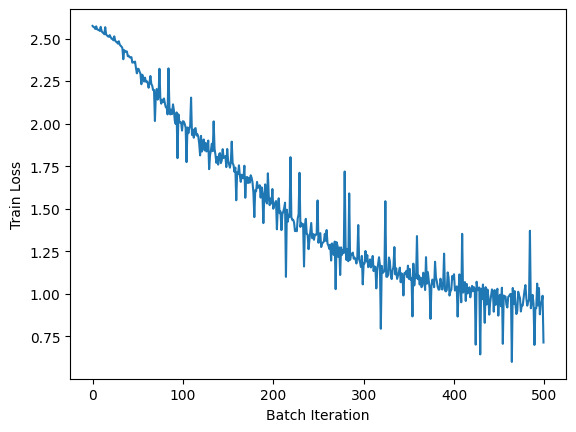

In [ ]:
plt.plot([i for i in range(len(all_loss))], all_loss, label="Train")
plt.xlabel('Batch Iteration')
plt.ylabel('Train Loss')
plt.show()

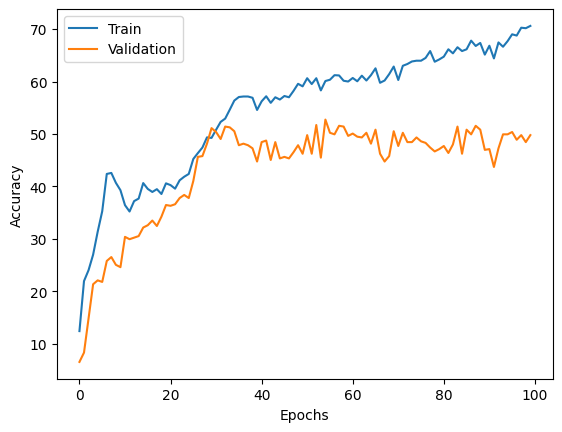

In [ ]:
# Plot training and validation accuracy over epochs
plt.plot([i for i in range(len(train_accuracy_list))], train_accuracy_list, label="Train")
plt.plot([i for i in range(len(validation_accuracy_list))], validation_accuracy_list, label="Validation")
plt.legend(loc="upper left")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

## Hyperparameters Set2

In [ ]:
# Hyperparameters
input_size = X_train.shape[2]
hidden_size = 128
num_classes = len(all_labels)   # automatically set correct number of classes
epochs = 100
learning_rate = 0.0001
batch_size = 256
landa = 0.000001

In [ ]:
# ---------------------------------------------------
# STEP 1: Encode labels safely into [0..11]
# ---------------------------------------------------
print("Original y_train labels:", np.unique(y_train))
print("Original y_test labels:", np.unique(y_test))

# Build mapping from all labels found in train and test
all_labels = np.unique(np.concatenate([y_train, y_test]))
label_to_index = {label: idx for idx, label in enumerate(sorted(all_labels))}

y_train = np.array([label_to_index[label] for label in y_train], dtype=np.int64)
y_test  = np.array([label_to_index[label] for label in y_test], dtype=np.int64)

print("Encoded y_train labels:", np.unique(y_train))
print("Encoded y_test labels:", np.unique(y_test))

# Data preparation
train_dataset = TensorDataset(
    t.tensor(X_train, dtype=t.float32),
    t.tensor(y_train, dtype=t.long)
)
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(
    t.tensor(X_test, dtype=t.float32),
    t.tensor(y_test, dtype=t.long)
)
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# RNN layers and additional fully connected layer
rnn_layer1 = nn.RNN(input_size, hidden_size, batch_first=True)
dropout1 = nn.Dropout(0.5)

fc_layer1 = nn.Linear(hidden_size, hidden_size // 2)
fc_layer2 = nn.Linear(hidden_size // 2, num_classes)

# Dropout layer
dropout_fc = nn.Dropout(0.2)

# Activation function
relu = nn.ReLU()

# Loss function
loss_fn = nn.CrossEntropyLoss()

# Lists to store accuracies and losses
all_loss = []
train_accuracy_list = []
validation_accuracy_list = []
train_loss_list = []

# Training loop
for epoch in range(epochs):

    if epoch % 10 == 0:
        learning_rate *= 0.9

    optimizer = Adam(
        list(rnn_layer1.parameters()) +
        list(fc_layer1.parameters()) +
        list(fc_layer2.parameters()),
        lr=learning_rate
    )

    per_epoch_loss_list = []

    for X, Y in train_data_loader:
        # Forward pass through layers
        out, _ = rnn_layer1(X)
        out = dropout1(out)
        out = out[:, -1, :]
        out = relu(fc_layer1(out))
        out = dropout_fc(out)
        out = fc_layer2(out)

        loss = loss_fn(out, Y)
        per_epoch_loss_list.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    all_loss += per_epoch_loss_list

    # Evaluation on training and validation data
    rnn_layer1.eval()
    fc_layer1.eval()
    fc_layer2.eval()

    with t.no_grad():
        # Training data
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            out, _ = rnn_layer1(X)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            train_total += Y.size(0)
            train_correct += (predicted == Y).sum().item()
        train_accuracy = 100 * train_correct / train_total

        # Validation data
        validation_correct, validation_total = 0, 0
        for X, Y in test_data_loader:
            out, _ = rnn_layer1(X)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            validation_total += Y.size(0)
            validation_correct += (predicted == Y).sum().item()
        validation_accuracy = 100 * validation_correct / validation_total

        print(f'Epoch {epoch+1}/{epochs} ---> Train Accuracy: {train_accuracy}%, Validation Accuracy: {validation_accuracy}%')

        train_accuracy_list.append(train_accuracy)
        validation_accuracy_list.append(validation_accuracy)

    train_loss_list.append(sum(per_epoch_loss_list) / len(per_epoch_loss_list))

    rnn_layer1.train()
    fc_layer1.train()
    fc_layer2.train()

Original y_train labels: [-2 -1  0  1  2  3  4  5  6  7  8  9]
Original y_test labels: [-2 -1  0  1  2  3  4  5  6  7  8  9]
Encoded y_train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Encoded y_test labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Epoch 1/100 ---> Train Accuracy: 4.552058111380146%, Validation Accuracy: 8.88888888888889%
Epoch 2/100 ---> Train Accuracy: 4.358353510895884%, Validation Accuracy: 9.925925925925926%
Epoch 3/100 ---> Train Accuracy: 6.779661016949152%, Validation Accuracy: 10.666666666666666%
Epoch 4/100 ---> Train Accuracy: 14.334140435835351%, Validation Accuracy: 13.925925925925926%
Epoch 5/100 ---> Train Accuracy: 21.307506053268764%, Validation Accuracy: 16.59259259259259%
Epoch 6/100 ---> Train Accuracy: 26.150121065375302%, Validation Accuracy: 17.77777777777778%
Epoch 7/100 ---> Train Accuracy: 30.605326876513317%, Validation Accuracy: 19.40740740740741%
Epoch 8/100 ---> Train Accuracy: 29.63680387409201%, Validation Accuracy: 19.703703703703702%
Ep

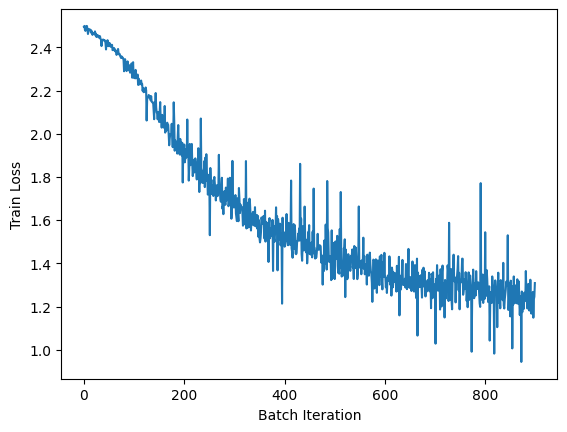

In [ ]:
plt.plot([i for i in range(len(all_loss))], all_loss, label="Train")
plt.xlabel('Batch Iteration')
plt.ylabel('Train Loss')
plt.show()

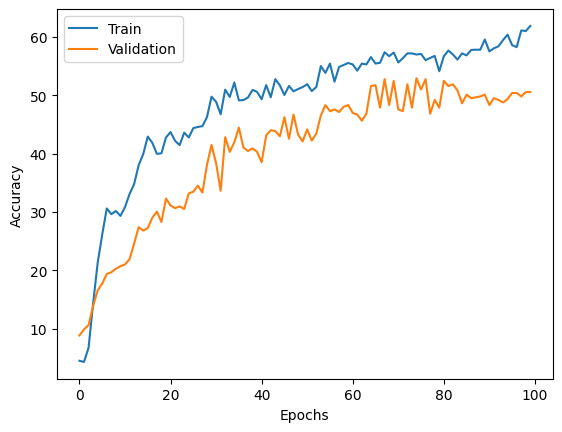

In [ ]:
# Plot training and validation accuracy over epochs
plt.plot([i for i in range(len(train_accuracy_list))], train_accuracy_list, label="Train")
plt.plot([i for i in range(len(validation_accuracy_list))], validation_accuracy_list, label="Validation")
plt.legend(loc="upper left")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

## Hyperparameters Set3

In [ ]:
# Hyperparameters
input_size = X_train.shape[2]
hidden_size = 64
num_classes = len(all_labels)   # automatically set correct number of classes
epochs = 100
learning_rate = 0.0001
batch_size = 128
landa = 0.00001

In [ ]:
# ---------------------------------------------------
# STEP 1: Encode labels safely into [0..11]
# ---------------------------------------------------
print("Original y_train labels:", np.unique(y_train))
print("Original y_test labels:", np.unique(y_test))

# Build mapping from all labels found in train and test
all_labels = np.unique(np.concatenate([y_train, y_test]))
label_to_index = {label: idx for idx, label in enumerate(sorted(all_labels))}

y_train = np.array([label_to_index[label] for label in y_train], dtype=np.int64)
y_test  = np.array([label_to_index[label] for label in y_test], dtype=np.int64)

print("Encoded y_train labels:", np.unique(y_train))
print("Encoded y_test labels:", np.unique(y_test))

# Data preparation
train_dataset = TensorDataset(
    t.tensor(X_train, dtype=t.float32),
    t.tensor(y_train, dtype=t.long)
)
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(
    t.tensor(X_test, dtype=t.float32),
    t.tensor(y_test, dtype=t.long)
)
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# RNN layers and additional fully connected layer
rnn_layer1 = nn.RNN(input_size, hidden_size, batch_first=True)
dropout1 = nn.Dropout(0.5)

fc_layer1 = nn.Linear(hidden_size, hidden_size // 2)
fc_layer2 = nn.Linear(hidden_size // 2, num_classes)

# Dropout layer
dropout_fc = nn.Dropout(0.2)

# Activation function
relu = nn.ReLU()

# Loss function
loss_fn = nn.CrossEntropyLoss()

# Lists to store accuracies and losses
all_loss = []
train_accuracy_list = []
validation_accuracy_list = []
train_loss_list = []

# Training loop
for epoch in range(epochs):

    if epoch % 10 == 0:
        learning_rate *= 0.9

    optimizer = Adam(
        list(rnn_layer1.parameters()) +
        list(fc_layer1.parameters()) +
        list(fc_layer2.parameters()),
        lr=learning_rate
    )

    per_epoch_loss_list = []

    for X, Y in train_data_loader:
        # Forward pass through layers
        out, _ = rnn_layer1(X)
        out = dropout1(out)
        out = out[:, -1, :]
        out = relu(fc_layer1(out))
        out = dropout_fc(out)
        out = fc_layer2(out)

        loss = loss_fn(out, Y)
        per_epoch_loss_list.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    all_loss += per_epoch_loss_list

    # Evaluation on training and validation data
    rnn_layer1.eval()
    fc_layer1.eval()
    fc_layer2.eval()

    with t.no_grad():
        # Training data
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            out, _ = rnn_layer1(X)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            train_total += Y.size(0)
            train_correct += (predicted == Y).sum().item()
        train_accuracy = 100 * train_correct / train_total

        # Validation data
        validation_correct, validation_total = 0, 0
        for X, Y in test_data_loader:
            out, _ = rnn_layer1(X)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            validation_total += Y.size(0)
            validation_correct += (predicted == Y).sum().item()
        validation_accuracy = 100 * validation_correct / validation_total

        print(f'Epoch {epoch+1}/{epochs} ---> Train Accuracy: {train_accuracy}%, Validation Accuracy: {validation_accuracy}%')

        train_accuracy_list.append(train_accuracy)
        validation_accuracy_list.append(validation_accuracy)

    train_loss_list.append(sum(per_epoch_loss_list) / len(per_epoch_loss_list))

    rnn_layer1.train()
    fc_layer1.train()
    fc_layer2.train()

Original y_train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Original y_test labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Encoded y_train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Encoded y_test labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Epoch 1/100 ---> Train Accuracy: 12.88135593220339%, Validation Accuracy: 5.62962962962963%
Epoch 2/100 ---> Train Accuracy: 14.624697336561743%, Validation Accuracy: 7.407407407407407%
Epoch 3/100 ---> Train Accuracy: 21.2590799031477%, Validation Accuracy: 13.62962962962963%
Epoch 4/100 ---> Train Accuracy: 24.358353510895885%, Validation Accuracy: 18.51851851851852%
Epoch 5/100 ---> Train Accuracy: 24.74576271186441%, Validation Accuracy: 19.555555555555557%
Epoch 6/100 ---> Train Accuracy: 27.74818401937046%, Validation Accuracy: 21.48148148148148%
Epoch 7/100 ---> Train Accuracy: 31.138014527845037%, Validation Accuracy: 27.25925925925926%
Epoch 8/100 ---> Train Accuracy: 33.026634382566584%, Validation Accuracy: 29.48148148148148%
Epoch

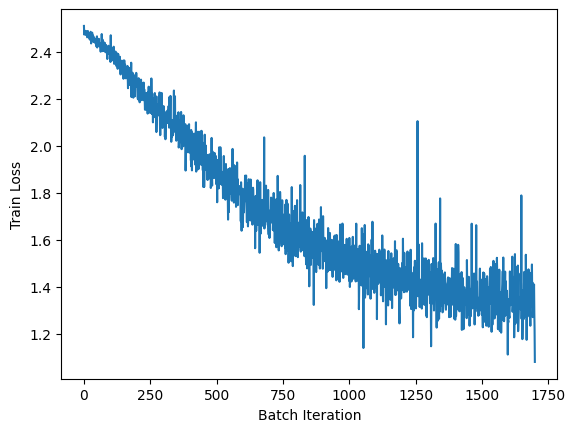

In [ ]:
plt.plot([i for i in range(len(all_loss))], all_loss, label="Train")
plt.xlabel('Batch Iteration')
plt.ylabel('Train Loss')
plt.show()

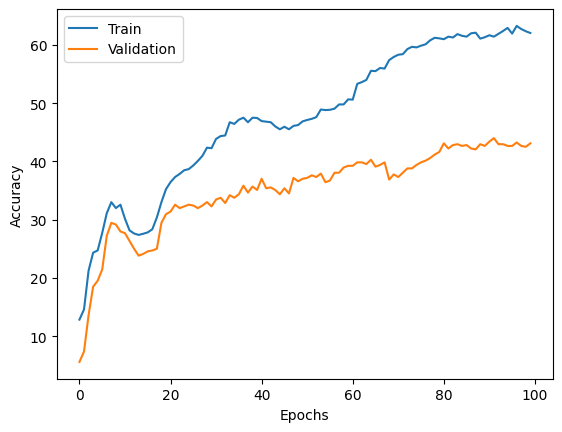

In [ ]:
# Plot training and validation accuracy over epochs
plt.plot([i for i in range(len(train_accuracy_list))], train_accuracy_list, label="Train")
plt.plot([i for i in range(len(validation_accuracy_list))], validation_accuracy_list, label="Validation")
plt.legend(loc="upper left")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# LSTM with PyTorch

## Hyperparameters Set1

In [ ]:
# Data preparation
train_dataset = TensorDataset(t.tensor(X_train, dtype=t.float32), t.tensor(y_train, dtype=t.long))
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(t.tensor(X_test, dtype=t.float32), t.tensor(y_test, dtype=t.long))
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# RNN layers and additional fully connected layer
rnn_layer1 = nn.LSTM(input_size, hidden_size, batch_first=True)
dropout1 = nn.Dropout(0.5)  # Add dropout between RNN layers
# rnn_layer2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
# dropout2 = nn.Dropout(0.5)  # Add dropout between RNN layers
fc_layer1 = nn.Linear(hidden_size, hidden_size)  # Additional fully connected layer
fc_layer2 = nn.Linear(hidden_size, num_classes)  # Final output layer

# Dropout layer
dropout_fc = nn.Dropout(0.2)  # Add dropout between fully connected layers

# Activation function
relu = nn.ReLU()

# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
# optimizer = Adam(list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)
optimizer = Adam(list(rnn_layer1.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)

# Lists to store accuracies and losses
train_accuracy_list = []
validation_accuracy_list = []
train_loss_list = []

# Training loop
for epoch in range(epochs):
    if epoch % 10 == 0:
        learning_rate *= 0.9  # Learning rate scheduling

    per_epoch_loss_list = []
    for X, Y in train_data_loader:
        # Forward pass through layers
        out, _ = rnn_layer1(X)
        out = dropout1(out)  # Apply dropout between RNN layers
        # out, _ = rnn_layer2(out)
        # out = dropout2(out)  # Apply dropout between RNN layers
        out = out[:, -1, :]  # Get the last output of the sequence
        out = relu(fc_layer1(out))  # Apply activation function after first fully connected layer
        out = dropout_fc(out)  # Apply dropout between fully connected layers
        out = fc_layer2(out)

        # Regularization
        # l2_term = sum([(w ** 2).sum() for w in list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters())])
        # loss = loss_fn(out, Y) + landa * l2_term
        loss = loss_fn(out, Y)

        per_epoch_loss_list.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluation on training and validation data
    rnn_layer1.eval()
    # rnn_layer2.eval()
    fc_layer1.eval()
    fc_layer2.eval()

    with t.no_grad():
        # Training data
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            out, _ = rnn_layer1(X)
            out = dropout1(out)  # Apply dropout between RNN layers
            # out, _ = rnn_layer2(out)
            # out = dropout2(out)  # Apply dropout between RNN layers
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = dropout_fc(out)  # Apply dropout between fully connected layers
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            train_total += Y.size(0)
            train_correct += (predicted == Y).sum().item()
        train_accuracy = 100 * train_correct / train_total

        # Validation data
        validation_correct, validation_total = 0, 0
        for X, Y in test_data_loader:
            out, _ = rnn_layer1(X)
            out = dropout1(out)  # Apply dropout between RNN layers
            # out, _ = rnn_layer2(out)
            # out = dropout2(out)  # Apply dropout between RNN layers
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = dropout_fc(out)  # Apply dropout between fully connected layers
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            validation_total += Y.size(0)
            validation_correct += (predicted == Y).sum().item()
        validation_accuracy = 100 * validation_correct / validation_total

        # Print accuracy for the current epoch
        print(f'Epoch {epoch}/{epochs} ---> Train Accuracy: {train_accuracy}%, Validation Accuracy: {validation_accuracy}%')

        # Append accuracy values to lists
        train_accuracy_list.append(train_accuracy)
        validation_accuracy_list.append(validation_accuracy)

    # Calculate and append the average loss for the epoch
    train_loss_list.append(sum(per_epoch_loss_list) / len(per_epoch_loss_list))

    # Set the model back to train mode
    rnn_layer1.train()
    # rnn_layer2.train()
    fc_layer1.train()
    fc_layer2.train()


Epoch 0/100 ---> Train Accuracy: 40.43583535108959%, Validation Accuracy: 26.666666666666668%
Epoch 1/100 ---> Train Accuracy: 40.19370460048426%, Validation Accuracy: 20.88888888888889%
Epoch 2/100 ---> Train Accuracy: 39.66101694915254%, Validation Accuracy: 26.962962962962962%
Epoch 3/100 ---> Train Accuracy: 40.58111380145279%, Validation Accuracy: 32.0%
Epoch 4/100 ---> Train Accuracy: 46.828087167070215%, Validation Accuracy: 33.925925925925924%
Epoch 5/100 ---> Train Accuracy: 56.70702179176755%, Validation Accuracy: 36.0%
Epoch 6/100 ---> Train Accuracy: 53.171912832929785%, Validation Accuracy: 39.7037037037037%
Epoch 7/100 ---> Train Accuracy: 52.590799031477%, Validation Accuracy: 32.74074074074074%
Epoch 8/100 ---> Train Accuracy: 56.3680387409201%, Validation Accuracy: 37.925925925925924%
Epoch 9/100 ---> Train Accuracy: 60.96852300242131%, Validation Accuracy: 41.925925925925924%
Epoch 10/100 ---> Train Accuracy: 64.21307506053269%, Validation Accuracy: 44.44444444444444%

## Hyperparameters Set2

In [ ]:
# ---------------------------------------------------
#  Hyperparameters
# ---------------------------------------------------
input_size    = X_train.shape[2]   # 12 sensor features
hidden_size   = 64
num_classes   = len(all_labels)    # 13 activity classes
epochs        = 100
learning_rate = 0.0001
batch_size    = 128
patience      = 10                 # early stopping patience

In [ ]:
# ---------------------------------------------------
# STEP 1: Encode labels safely into [0..N-1]
# ---------------------------------------------------
print("Original y_train labels:", np.unique(y_train))
print("Original y_test  labels:", np.unique(y_test))

all_labels    = np.unique(np.concatenate([y_train, y_test]))
label_to_index = {label: idx for idx, label in enumerate(sorted(all_labels))}

y_train = np.array([label_to_index[l] for l in y_train], dtype=np.int64)
y_test  = np.array([label_to_index[l] for l in y_test],  dtype=np.int64)

print("Encoded y_train labels:", np.unique(y_train))
print("Encoded y_test  labels:", np.unique(y_test))

# ---------------------------------------------------
# STEP 2: DataLoaders
# ---------------------------------------------------
train_dataset = TensorDataset(
    t.tensor(X_train, dtype=t.float32),
    t.tensor(y_train, dtype=t.long)
)
test_dataset = TensorDataset(
    t.tensor(X_test, dtype=t.float32),
    t.tensor(y_test, dtype=t.long)
)

train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# ---------------------------------------------------
# STEP 3: RNN Model as nn.Module
# ---------------------------------------------------
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(RNNClassifier, self).__init__()

        self.rnn      = nn.RNN(input_size, hidden_size, batch_first=True)
        self.dropout1 = nn.Dropout(0.5)

        self.fc1      = nn.Linear(hidden_size, hidden_size // 2)
        self.relu     = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.fc2      = nn.Linear(hidden_size // 2, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)          # (batch, 200, hidden_size)
        out    = self.dropout1(out)
        out    = out[:, -1, :]        # take last timestep → (batch, hidden_size)
        out    = self.relu(self.fc1(out))
        out    = self.dropout2(out)
        out    = self.fc2(out)        # raw logits → (batch, num_classes)
        return out

model     = RNNClassifier(input_size, hidden_size, num_classes)
loss_fn   = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=learning_rate)

# ---------------------------------------------------
# STEP 4: Model Evaluation Function
# ---------------------------------------------------
def test_model(model, data_loader, loss_fn, epoch_num):
    model.eval()
    total_loss = 0
    count      = 0
    y_true     = []
    y_pred     = []

    with t.no_grad():
        with tqdm(enumerate(data_loader), total=len(data_loader)) as p:
            for i, (X, Y) in p:
                output      = model(X)
                loss        = loss_fn(output, Y)
                total_loss += loss.item()
                count      += len(Y)
                y_true.extend(Y.cpu().numpy())
                y_pred.extend(output.argmax(dim=1).cpu().numpy())
                p.set_postfix({'batch_loss': loss.item()})

    acc      = accuracy_score(y_true, y_pred)
    prec     = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec      = recall_score(y_true, y_pred,    average='macro', zero_division=0)
    f1       = f1_score(y_true, y_pred,        average='macro', zero_division=0)
    avg_loss = total_loss / count

    print(f'\nEpoch {epoch_num} Evaluation')
    print(f'{"="*55}')
    print(f'Average Loss : {avg_loss:.4f}')
    print(f'Accuracy     : {acc*100:.2f}%')
    print(f'Precision    : {prec:.4f}  (macro)')
    print(f'Recall       : {rec:.4f}  (macro)')
    print(f'F1 Score     : {f1:.4f}  (macro)')
    print(f'{"="*55}')

    activity_names = [
        'Nothing', 'Standing still', 'Sitting & relaxing', 'Lying down',
        'Walking', 'Climbing stairs', 'Waist bends forward',
        'Frontal elevation arms', 'Knees bending', 'Cycling',
        'Jogging', 'Running', 'Jump front & back'
    ]
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=activity_names,
                                zero_division=0, digits=4))
    return avg_loss, [acc, prec, rec, f1], y_true, y_pred

# ---------------------------------------------------
# STEP 5: Training Loop with Early Stopping
# ---------------------------------------------------
train_loss_list        = []
train_accuracy_list    = []
validation_accuracy_list = []

best_model_state = None
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(epochs):

    # Decay learning rate every 10 epochs
    if epoch % 10 == 0 and epoch > 0:
        for g in optimizer.param_groups:
            g['lr'] *= 0.9

    model.train()
    per_epoch_loss = []

    for X, Y in train_data_loader:
        optimizer.zero_grad()
        out  = model(X)
        loss = loss_fn(out, Y)
        loss.backward()
        optimizer.step()
        per_epoch_loss.append(loss.item())

    avg_train_loss = sum(per_epoch_loss) / len(per_epoch_loss)
    train_loss_list.append(avg_train_loss)

    # ── Accuracy on train & val (no dropout) ──
    model.eval()
    with t.no_grad():
        # Train accuracy
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            preds = model(X).argmax(dim=1)
            train_correct += (preds == Y).sum().item()
            train_total   += Y.size(0)
        train_acc = 100 * train_correct / train_total

        # Validation accuracy + loss (for early stopping)
        val_correct, val_total, val_loss_sum = 0, 0, 0.0
        for X, Y in test_data_loader:
            out = model(X)
            val_loss_sum += loss_fn(out, Y).item() * len(Y)
            preds = out.argmax(dim=1)
            val_correct += (preds == Y).sum().item()
            val_total   += Y.size(0)
        val_acc  = 100 * val_correct / val_total
        val_loss = val_loss_sum / val_total

    train_accuracy_list.append(train_acc)
    validation_accuracy_list.append(val_acc)

    print(f'Epoch {epoch+1}/{epochs} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Train Acc: {train_acc:.2f}% | '
          f'Val Acc: {val_acc:.2f}%')

    # ── Early Stopping ──
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_model_state = {
            "model": copy.deepcopy(model.state_dict()),
            "epoch": epoch + 1
        }
    else:
        patience_counter += 1
        print(patience_counter)
        if patience_counter >= patience:
            print(f'\nEarly stopping at epoch {epoch+1} '
                  f'(no improvement for {patience} epochs)')
            break



Original y_train labels: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Original y_test  labels: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Encoded y_train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Encoded y_test  labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Epoch 1/100 | Train Loss: 2.4907 | Train Acc: 10.46% | Val Acc: 10.96%
Epoch 2/100 | Train Loss: 2.4706 | Train Acc: 11.67% | Val Acc: 13.19%
Epoch 3/100 | Train Loss: 2.4565 | Train Acc: 14.58% | Val Acc: 16.59%
Epoch 4/100 | Train Loss: 2.4370 | Train Acc: 17.05% | Val Acc: 17.93%
Epoch 5/100 | Train Loss: 2.4267 | Train Acc: 18.21% | Val Acc: 19.41%
Epoch 6/100 | Train Loss: 2.4087 | Train Acc: 18.93% | Val Acc: 19.56%
Epoch 7/100 | Train Loss: 2.3884 | Train Acc: 19.18% | Val Acc: 19.11%
Epoch 8/100 | Train Loss: 2.3692 | Train Acc: 24.21% | Val Acc: 24.00%
Epoch 9/100 | Train Loss: 2.3379 | Train Acc: 27.60% | Val Acc: 24.00%
Epoch 10/100 | Train Loss: 2.3215 | Train Acc: 27.94% | Val Acc: 24.74%
Epoch 11/100 | Train Loss: 2.2940 | Tra

### Model Evaluation

In [ ]:
# MODEL EVALUATION FUNCTION
def test_model(model, data_loader, loss_fn, epoch_num):
    model.eval()

    total_loss = 0
    count      = 0
    y_true     = []
    y_pred     = []

    with t.no_grad():
        with tqdm(enumerate(data_loader), total=len(data_loader)) as p:
            for i, (X, Y) in p:

                # Forward pass
                output = model(X)
                loss   = loss_fn(output, Y)

                total_loss += loss.item()
                count      += len(Y)

                y_true.extend(Y.cpu().numpy())
                y_pred.extend(output.argmax(dim=1).cpu().numpy())  # predicted class

                # Update tqdm progress bar with running loss
                p.set_postfix({'batch_loss': loss.item()})

    # -----------------------------
    # Metrics
    # -----------------------------
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='macro', zero_division=0)

    avg_loss = total_loss / count

    # -----------------------------
    # Print summary
    # -----------------------------
    print(f'\nEpoch {epoch_num} Evaluation')
    print(f'{"="*55}')
    print(f'Average Loss : {avg_loss:.4f}')
    print(f'Accuracy     : {acc*100:.2f}%')
    print(f'Precision    : {prec:.4f}  (macro)')
    print(f'Recall       : {rec:.4f}   (macro)')
    print(f'F1 Score     : {f1:.4f}    (macro)')
    print(f'{"="*55}')

    # -----------------------------
    # Full classification report
    # -----------------------------
    activity_names = [f'Activity {i}' for i in range(num_classes)]
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=activity_names,
                                zero_division=0, digits=4))



    return avg_loss, [acc, prec, rec, f1], y_true, y_pred


Loaded best model from epoch 52

Evaluating best model on test set...


100%|██████████| 6/6 [00:00<00:00, 24.54it/s, batch_loss=2.09]



Epoch 52 Evaluation
Average Loss : 0.0170
Accuracy     : 32.59%
Precision    : 0.2450  (macro)
Recall       : 0.3047   (macro)
F1 Score     : 0.2309    (macro)

Classification Report:
              precision    recall  f1-score   support

  Activity 0     0.0000    0.0000    0.0000        60
  Activity 1     0.0000    0.0000    0.0000        62
  Activity 2     0.4766    1.0000    0.6455        61
  Activity 3     0.2632    0.9836    0.4152        61
  Activity 4     0.0000    0.0000    0.0000        60
  Activity 5     0.0000    0.0000    0.0000        54
  Activity 6     0.3673    0.3333    0.3495        54
  Activity 7     0.2396    0.4035    0.3007        57
  Activity 8     1.0000    0.5000    0.6667        62
  Activity 9     0.2300    0.3710    0.2840        62
 Activity 10     0.3636    0.0645    0.1096        62
 Activity 11     0.0000    0.0000    0.0000        20

    accuracy                         0.3259       675
   macro avg     0.2450    0.3047    0.2309       675
wei

ValueError: The number of FixedLocator locations (12), usually from a call to set_ticks, does not match the number of labels (13).

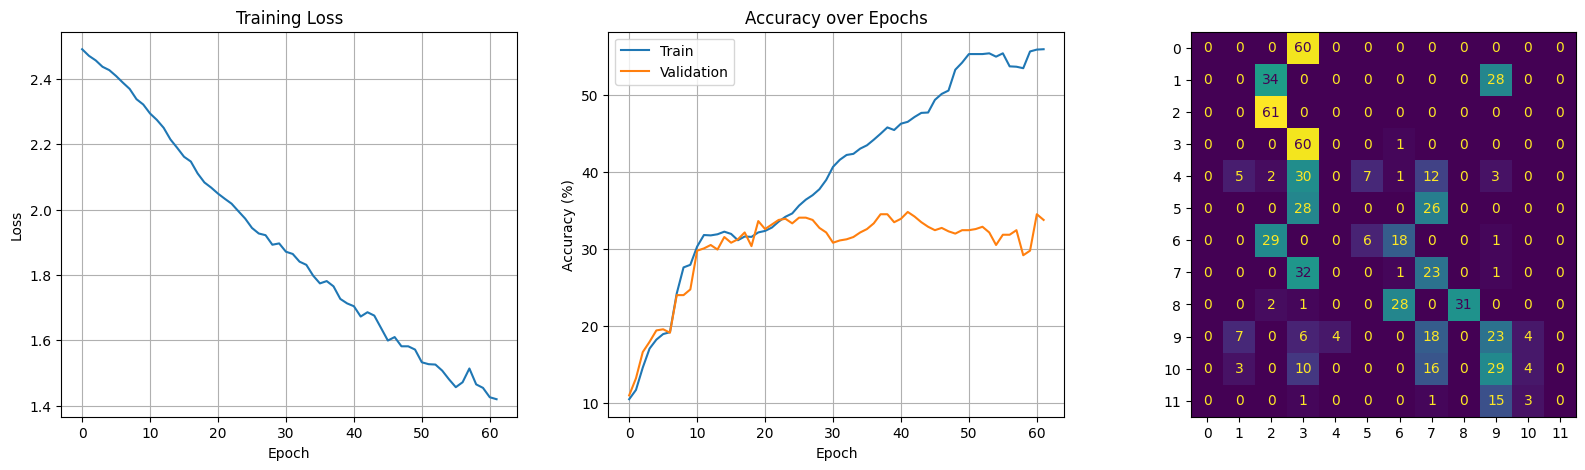

In [ ]:
# ---------------------------------------------------
# Evaluate Best Model
# ---------------------------------------------------
if best_model_state is not None:
    model.load_state_dict(best_model_state["model"])
    print(f'\nLoaded best model from epoch {best_model_state["epoch"]}')

print("\nEvaluating best model on test set...")
avg_loss, metrics, y_true, y_pred = test_model(
    model, test_data_loader, loss_fn, epoch_num=best_model_state["epoch"]
)
acc, prec, rec, f1 = metrics

print(f'\nFinal Test Results:')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1        : {f1:.4f}')

# ---------------------------------------------------
# STEP 8: Plots
# ---------------------------------------------------
activity_names = [
    'Nothing', 'Standing', 'Sitting', 'Lying',
    'Walking', 'Stairs', 'Waist bend',
    'Arm raise', 'Knee bend', 'Cycling',
    'Jogging', 'Running', 'Jump'
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss curve
axes[0].plot(train_loss_list)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Accuracy curves
axes[1].plot(train_accuracy_list,      label='Train')
axes[1].plot(validation_accuracy_list, label='Validation')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_names)
disp.plot(ax=axes[2], xticks_rotation=45, colorbar=False)
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

## Hyperparameters Set3

In [ ]:
# Hyperparameters
input_size = X_train.shape[2]
hidden_size = 256  # Number of hidden units
num_classes = 12  # For three-class classification
epochs = 100
learning_rate = 0.001
batch_size = 512
landa = 0.001  # Regularization term (lambda)

# Data preparation
train_dataset = TensorDataset(t.tensor(X_train, dtype=t.float32), t.tensor(y_train, dtype=t.long))
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(t.tensor(X_test, dtype=t.float32), t.tensor(y_test, dtype=t.long))
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# RNN layers and additional fully connected layer
rnn_layer1 = nn.LSTM(input_size, hidden_size, batch_first=True)
dropout1 = nn.Dropout(0.5)  # Add dropout between RNN layers
# rnn_layer2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
# dropout2 = nn.Dropout(0.5)  # Add dropout between RNN layers
fc_layer1 = nn.Linear(hidden_size, hidden_size)  # Additional fully connected layer
fc_layer2 = nn.Linear(hidden_size, num_classes)  # Final output layer

# Dropout layer
dropout_fc = nn.Dropout(0.2)  # Add dropout between fully connected layers

# Activation function
relu = nn.ReLU()

# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
# optimizer = Adam(list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)
optimizer = Adam(list(rnn_layer1.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)

# Lists to store accuracies and losses
train_accuracy_list = []
validation_accuracy_list = []
train_loss_list = []

# Training loop
for epoch in range(epochs):
    if epoch % 10 == 0:
        learning_rate *= 0.9  # Learning rate scheduling

    per_epoch_loss_list = []
    for X, Y in train_data_loader:
        # Forward pass through layers
        out, _ = rnn_layer1(X)
        out = dropout1(out)  # Apply dropout between RNN layers
        # out, _ = rnn_layer2(out)
        # out = dropout2(out)  # Apply dropout between RNN layers
        out = out[:, -1, :]  # Get the last output of the sequence
        out = relu(fc_layer1(out))  # Apply activation function after first fully connected layer
        out = dropout_fc(out)  # Apply dropout between fully connected layers
        out = fc_layer2(out)

        # Regularization
        # l2_term = sum([(w ** 2).sum() for w in list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters())])
        # loss = loss_fn(out, Y) + landa * l2_term
        loss = loss_fn(out, Y)

        per_epoch_loss_list.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluation on training and validation data
    rnn_layer1.eval()
    # rnn_layer2.eval()
    fc_layer1.eval()
    fc_layer2.eval()

    with t.no_grad():
        # Training data
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            out, _ = rnn_layer1(X)
            out = dropout1(out)  # Apply dropout between RNN layers
            # out, _ = rnn_layer2(out)
            # out = dropout2(out)  # Apply dropout between RNN layers
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = dropout_fc(out)  # Apply dropout between fully connected layers
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            train_total += Y.size(0)
            train_correct += (predicted == Y).sum().item()
        train_accuracy = 100 * train_correct / train_total

        # Validation data
        validation_correct, validation_total = 0, 0
        for X, Y in test_data_loader:
            out, _ = rnn_layer1(X)
            out = dropout1(out)  # Apply dropout between RNN layers
            # out, _ = rnn_layer2(out)
            # out = dropout2(out)  # Apply dropout between RNN layers
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = dropout_fc(out)  # Apply dropout between fully connected layers
            out = fc_layer2(out)
            _, predicted = t.max(out.data, 1)
            validation_total += Y.size(0)
            validation_correct += (predicted == Y).sum().item()
        validation_accuracy = 100 * validation_correct / validation_total

        # Print accuracy for the current epoch
        print(f'Epoch {epoch}/{epochs} ---> Train Accuracy: {train_accuracy}%, Validation Accuracy: {validation_accuracy}%')

        # Append accuracy values to lists
        train_accuracy_list.append(train_accuracy)
        validation_accuracy_list.append(validation_accuracy)

    # Calculate and append the average loss for the epoch
    train_loss_list.append(sum(per_epoch_loss_list) / len(per_epoch_loss_list))

    # Set the model back to train mode
    rnn_layer1.train()
    # rnn_layer2.train()
    fc_layer1.train()
    fc_layer2.train()


## Hyperparameters Set4

In [ ]:

print("Original y_train labels:", np.unique(y_train))
print("Original y_test  labels:", np.unique(y_test))

all_labels    = np.unique(np.concatenate([y_train, y_test]))
label_to_index = {label: idx for idx, label in enumerate(sorted(all_labels))}

y_train = np.array([label_to_index[l] for l in y_train], dtype=np.int64)
y_test  = np.array([label_to_index[l] for l in y_test],  dtype=np.int64)

print("Encoded y_train labels:", np.unique(y_train))
print("Encoded y_test  labels:", np.unique(y_test))

# ---------------------------------------------------
# Hyperparameters
# ---------------------------------------------------
input_size    = X_train.shape[2]
hidden_size   = 64
num_classes   = len(all_labels)
epochs        = 100
learning_rate = 0.001
batch_size    = 512
patience      = 10
# ---------------------------------------------------
# DataLoaders
# ---------------------------------------------------
train_dataset = TensorDataset(
    t.tensor(X_train, dtype=t.float32),
    t.tensor(y_train, dtype=t.long)
)
test_dataset = TensorDataset(
    t.tensor(X_test, dtype=t.float32),
    t.tensor(y_test, dtype=t.long)
)

train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# ---------------------------------------------------
# LSTM Model as nn.Module
# ---------------------------------------------------
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMClassifier, self).__init__()

        self.lstm     = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout1 = nn.Dropout(0.5)

        self.fc1      = nn.Linear(hidden_size, hidden_size)
        self.relu     = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.fc2      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.dropout1(out)
        out    = out[:, -1, :]
        out    = self.relu(self.fc1(out))
        out    = self.dropout2(out)
        out    = self.fc2(out)        # raw logits → (batch, num_classes)
        return out

model     = LSTMClassifier(input_size, hidden_size, num_classes)
loss_fn   = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=learning_rate)

# ---------------------------------------------------
# Model Evaluation Function
# ---------------------------------------------------
def test_model(model, data_loader, loss_fn, epoch_num):
    model.eval()
    total_loss = 0
    count      = 0
    y_true     = []
    y_pred     = []

    with t.no_grad():
        with tqdm(enumerate(data_loader), total=len(data_loader)) as p:
            for i, (X, Y) in p:
                output      = model(X)
                loss        = loss_fn(output, Y)
                total_loss += loss.item()
                count      += len(Y)
                y_true.extend(Y.cpu().numpy())
                y_pred.extend(output.argmax(dim=1).cpu().numpy())
                p.set_postfix({'batch_loss': loss.item()})

    acc      = accuracy_score(y_true, y_pred)
    prec     = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec      = recall_score(y_true, y_pred,    average='macro', zero_division=0)
    f1       = f1_score(y_true, y_pred,        average='macro', zero_division=0)
    avg_loss = total_loss / count

    print(f'\nEpoch {epoch_num} Evaluation')
    print(f'{"="*55}')
    print(f'Average Loss : {avg_loss:.4f}')
    print(f'Accuracy     : {acc*100:.2f}%')
    print(f'Precision    : {prec:.4f}  (macro)')
    print(f'Recall       : {rec:.4f}  (macro)')
    print(f'F1 Score     : {f1:.4f}  (macro)')
    print(f'{"="*55}')

    activity_names = [
        'Nothing', 'Standing still', 'Sitting & relaxing', 'Lying down',
        'Walking', 'Climbing stairs', 'Waist bends forward',
        'Frontal elevation arms', 'Knees bending', 'Cycling',
        'Jogging', 'Running', 'Jump front & back'
    ]
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=activity_names,
                                zero_division=0, digits=4))
    return avg_loss, [acc, prec, rec, f1], y_true, y_pred

# ---------------------------------------------------
# Training Loop with Early Stopping
# ---------------------------------------------------
train_loss_list        = []
train_accuracy_list    = []
validation_accuracy_list = []

best_model_state = None
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(epochs):

    # Decay learning rate every 10 epochs
    if epoch % 10 == 0 and epoch > 0:
        for g in optimizer.param_groups:
            g['lr'] *= 0.9

    model.train()
    per_epoch_loss = []

    for X, Y in train_data_loader:
        optimizer.zero_grad()
        out  = model(X)
        loss = loss_fn(out, Y)
        loss.backward()
        optimizer.step()
        per_epoch_loss.append(loss.item())

    avg_train_loss = sum(per_epoch_loss) / len(per_epoch_loss)
    train_loss_list.append(avg_train_loss)

    # ── Accuracy on train & val (no dropout) ──
    model.eval()
    with t.no_grad():
        # Train accuracy
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            preds = model(X).argmax(dim=1)
            train_correct += (preds == Y).sum().item()
            train_total   += Y.size(0)
        train_acc = 100 * train_correct / train_total

        # Validation accuracy + loss (for early stopping)
        val_correct, val_total, val_loss_sum = 0, 0, 0.0
        for X, Y in test_data_loader:
            out = model(X)
            val_loss_sum += loss_fn(out, Y).item() * len(Y)
            preds = out.argmax(dim=1)
            val_correct += (preds == Y).sum().item()
            val_total   += Y.size(0)
        val_acc  = 100 * val_correct / val_total
        val_loss = val_loss_sum / val_total

    train_accuracy_list.append(train_acc)
    validation_accuracy_list.append(val_acc)

    print(f'Epoch {epoch+1}/{epochs} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Train Acc: {train_acc:.2f}% | '
          f'Val Acc: {val_acc:.2f}%')

    # ── Early Stopping ──
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_model_state = {
            "model": copy.deepcopy(model.state_dict()),
            "epoch": epoch + 1
        }
    else:
        patience_counter += 1
        print(patience_counter)
        if patience_counter >= patience:
            print(f'\nEarly stopping at epoch {epoch+1} '
                  f'(no improvement for {patience} epochs)')
            break



Original y_train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Original y_test  labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Encoded y_train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Encoded y_test  labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Epoch 1/100 | Train Loss: 2.4861 | Train Acc: 7.70% | Val Acc: 5.63%
Epoch 2/100 | Train Loss: 2.4518 | Train Acc: 25.81% | Val Acc: 24.15%
Epoch 3/100 | Train Loss: 2.4292 | Train Acc: 39.47% | Val Acc: 27.70%
Epoch 4/100 | Train Loss: 2.3932 | Train Acc: 43.58% | Val Acc: 26.81%
Epoch 5/100 | Train Loss: 2.3425 | Train Acc: 43.97% | Val Acc: 30.96%
Epoch 6/100 | Train Loss: 2.2393 | Train Acc: 42.91% | Val Acc: 30.81%
Epoch 7/100 | Train Loss: 2.1525 | Train Acc: 41.31% | Val Acc: 30.52%
Epoch 8/100 | Train Loss: 2.0683 | Train Acc: 41.07% | Val Acc: 30.52%
Epoch 9/100 | Train Loss: 1.9431 | Train Acc: 42.28% | Val Acc: 33.04%
Epoch 10/100 | Train Loss: 1.8691 | Train Acc: 45.38% | Val Acc: 33.78%
Epoch 11/100 | Train Loss: 1.7516 | Train

### Model Evaluation

In [ ]:
def test_model(model, data_loader, loss_fn, epoch_num):
    model.eval()
    total_loss = 0
    count      = 0
    y_true     = []
    y_pred     = []

    with t.no_grad():
        with tqdm(enumerate(data_loader), total=len(data_loader)) as p:
            for i, (X, Y) in p:
                output      = model(X)
                loss        = loss_fn(output, Y)
                total_loss += loss.item()
                count      += len(Y)
                y_true.extend(Y.cpu().numpy())
                y_pred.extend(output.argmax(dim=1).cpu().numpy())
                p.set_postfix({'batch_loss': loss.item()})

    acc      = accuracy_score(y_true, y_pred)
    prec     = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec      = recall_score(y_true, y_pred,    average='macro', zero_division=0)
    f1       = f1_score(y_true, y_pred,        average='macro', zero_division=0)
    avg_loss = total_loss / count

    print(f'\nEpoch {epoch_num} Evaluation')
    print(f'{"="*55}')
    print(f'Average Loss : {avg_loss:.4f}')
    print(f'Accuracy     : {acc*100:.2f}%')
    print(f'Precision    : {prec:.4f}  (macro)')
    print(f'Recall       : {rec:.4f}  (macro)')
    print(f'F1 Score     : {f1:.4f}  (macro)')
    print(f'{"="*55}')

    activity_names = [f'Activity {i}' for i in range(num_classes)]
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=activity_names,
                                zero_division=0, digits=4))

    return avg_loss, [acc, prec, rec, f1], y_true, y_pred  # ← must be here


Loaded best model from epoch 18

Evaluating best model on test set...


100%|██████████| 2/2 [00:00<00:00,  3.60it/s, batch_loss=2.15]



Epoch 18 Evaluation
Average Loss : 0.0054
Accuracy     : 36.15%
Precision    : 0.3412  (macro)
Recall       : 0.3446  (macro)
F1 Score     : 0.3039  (macro)

Classification Report:
              precision    recall  f1-score   support

  Activity 0     0.4138    0.2000    0.2697        60
  Activity 1     0.0000    0.0000    0.0000        62
  Activity 2     1.0000    0.5082    0.6739        61
  Activity 3     0.7576    0.4098    0.5319        61
  Activity 4     0.0000    0.0000    0.0000        60
  Activity 5     0.1351    0.0926    0.1099        54
  Activity 6     0.3458    0.6852    0.4596        54
  Activity 7     0.2821    0.9649    0.4365        57
  Activity 8     0.9038    0.7581    0.8246        62
  Activity 9     0.0161    0.0161    0.0161        62
 Activity 10     0.2403    0.5000    0.3246        62
 Activity 11     0.0000    0.0000    0.0000        20

    accuracy                         0.3615       675
   macro avg     0.3412    0.3446    0.3039       675
weight

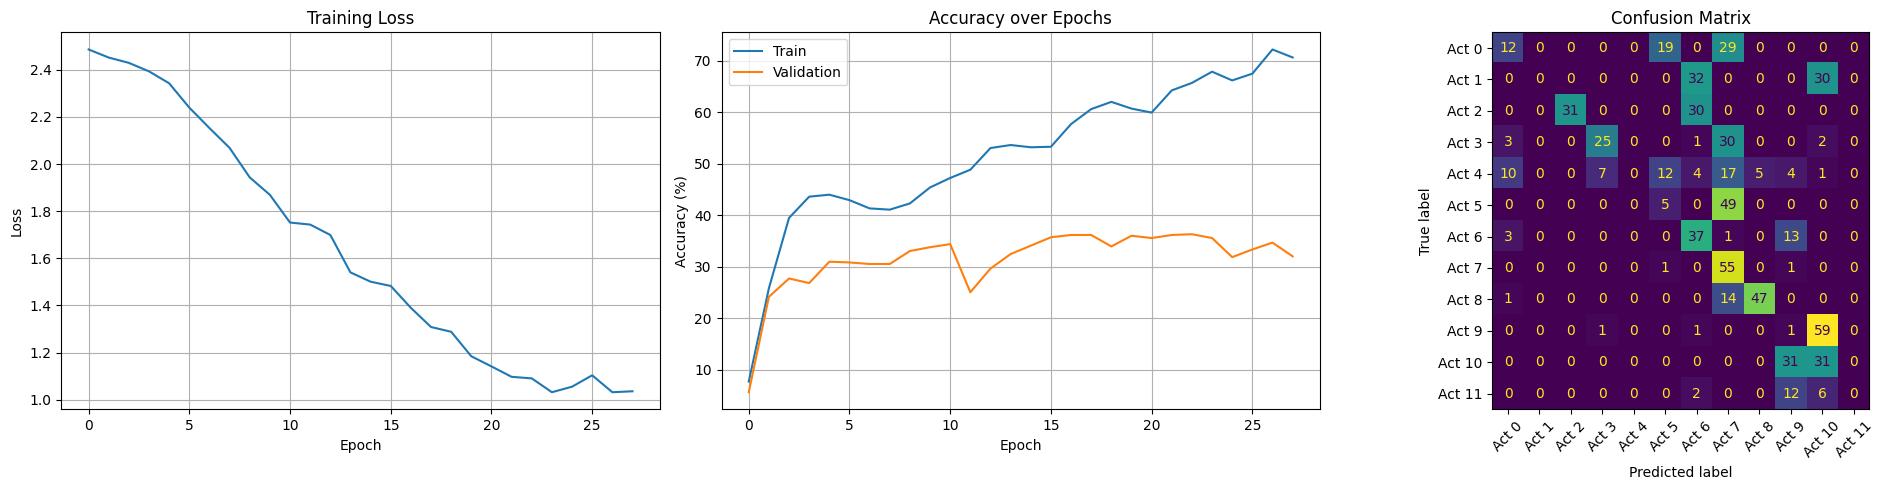

In [ ]:
# ---------------------------------------------------
# Evaluate Best Model
# ---------------------------------------------------
if best_model_state is not None:
    model.load_state_dict(best_model_state["model"])
    print(f'\nLoaded best model from epoch {best_model_state["epoch"]}')

print("\nEvaluating best model on test set...")
avg_loss, metrics, y_true, y_pred = test_model(
    model, test_data_loader, loss_fn, epoch_num=best_model_state["epoch"]
)
acc, prec, rec, f1 = metrics

print(f'\nFinal Test Results:')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1        : {f1:.4f}')

# ---------------------------------------------------
# Plots
# ---------------------------------------------------
activity_names = [
    'Nothing', 'Standing', 'Sitting', 'Lying',
    'Walking', 'Stairs', 'Waist bend',
    'Arm raise', 'Knee bend', 'Cycling',
    'Jogging', 'Running', 'Jump'
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss curve
axes[0].plot(train_loss_list)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Accuracy curves
axes[1].plot(train_accuracy_list,      label='Train')
axes[1].plot(validation_accuracy_list, label='Validation')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

# Confusion matrix
unique_classes = sorted(set(y_true) | set(y_pred))
cm   = confusion_matrix(y_true, y_pred, labels=unique_classes)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f'Act {i}' for i in unique_classes]
)
disp.plot(ax=axes[2], xticks_rotation=45, colorbar=False)
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()